# FER2013 — KD to MobileNetV3‑Small @ 224

This notebook trains a MobileNetV3‑Small student via knowledge distillation from an EfficientNet‑B0 teacher. The goal is to retain high accuracy while improving efficiency. Paths and core training code match the earlier version; additional report cells are appended for visualization.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, math, time, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

CSV_PATH = "/content/drive/MyDrive/Datasets/fer2013.csv"  # change if needed
BEST_TEACHER_PATH = "/content/drive/MyDrive/ComputerVision_outputs/best_model.pt"
OUTPUT_DIR = "/content/drive/MyDrive/FER2013_distilled_mnv3small"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS_STUDENT = 20
LR_STUDENT = 3e-4
WEIGHT_DECAY = 1e-4

T = 4.0
ALPHA = 0.3

print('CSV:', CSV_PATH)
print('Teacher ckpt:', BEST_TEACHER_PATH)
assert os.path.isfile(CSV_PATH), f'CSV not found at {CSV_PATH}'
assert os.path.isfile(BEST_TEACHER_PATH), f'Teacher checkpoint not found at {BEST_TEACHER_PATH}'


Mounted at /content/drive
Device: cuda
CSV: /content/drive/MyDrive/Datasets/fer2013.csv
Teacher ckpt: /content/drive/MyDrive/ComputerVision_outputs/best_model.pt


In [2]:
df = pd.read_csv(CSV_PATH)
cols = {c.lower(): c for c in df.columns}
emotion_col = cols.get('emotion'); pixels_col = cols.get('pixels'); usage_col = cols.get('usage')
assert emotion_col and pixels_col

def norm_usage(x: str) -> str:
    s = str(x).strip().lower()
    if 'train' in s: return 'Training'
    if 'public' in s or 'val' in s: return 'PublicTest'
    if 'private' in s or 'test' in s: return 'PrivateTest'
    return 'Training'

if usage_col is None:
    df['Usage'] = 'Training'
else:
    df['Usage'] = df[usage_col].apply(norm_usage)
df['emotion'] = df[emotion_col].astype(int)

df_train = df[df['Usage']=='Training'].copy()
df_val   = df[df['Usage']=='PublicTest'].copy()
df_test  = df[df['Usage']=='PrivateTest'].copy()

if len(df_val)==0 or len(df_test)==0:
    from sklearn.model_selection import StratifiedShuffleSplit
    y = df_train['emotion'].values
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(sss1.split(np.zeros(len(y)), y))
    temp_targets = y[temp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
    val_sub, test_sub = next(sss2.split(np.zeros(len(temp_targets)), temp_targets))
    val_idx = temp_idx[val_sub]; test_idx = temp_idx[test_sub]
    df_val = df_train.iloc[val_idx].copy()
    df_test = df_train.iloc[test_idx].copy()
    df_train = df_train.iloc[train_idx].copy()

num_classes = int(df['emotion'].nunique())
print('Split sizes (train/val/test):', len(df_train), len(df_val), len(df_test))

def build_transforms(img_size=224):
    train_tfms = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(img_size, scale=(0.8,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    eval_tfms = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(int(img_size*1.15)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return train_tfms, eval_tfms

class FER2013CsvDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.targets = self.df['emotion'].values.astype(int)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = np.fromstring(row['pixels'], dtype=np.uint8, sep=' ').reshape(48,48)
        img = Image.fromarray(arr, mode='L')
        if self.transform: img = self.transform(img)
        label = int(row['emotion'])
        return img, label

train_tfms, eval_tfms = build_transforms(IMG_SIZE)
ds_train = FER2013CsvDataset(df_train, transform=train_tfms)
ds_val   = FER2013CsvDataset(df_val,   transform=eval_tfms)
ds_test  = FER2013CsvDataset(df_test,  transform=eval_tfms)

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Split sizes (train/val/test): 28709 3589 3589


In [3]:
def build_teacher(num_classes):
    weights = getattr(models, 'EfficientNet_B0_Weights', None)
    m = models.efficientnet_b0(weights=weights.DEFAULT if weights else None)
    in_feats = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_feats, num_classes)
    m._backbone_name = 'efficientnet_b0'
    return m

def build_student(num_classes):
    weights = getattr(models, 'MobileNet_V3_Small_Weights', None)
    m = models.mobilenet_v3_small(weights=weights.DEFAULT if weights else None)
    in_feats = m.classifier[-1].in_features
    m.classifier[-1] = nn.Linear(in_feats, num_classes)
    m._backbone_name = 'mobilenet_v3_small'
    return m

teacher = build_teacher(num_classes).to(DEVICE)
ckpt = torch.load(BEST_TEACHER_PATH, map_location=DEVICE)
teacher.load_state_dict(ckpt['model'])
teacher.eval()
print('Loaded teacher:', getattr(teacher,'_backbone_name','?'))

student = build_student(num_classes).to(DEVICE)
print('Student:', getattr(student,'_backbone_name','?'))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 26.2MB/s]


Loaded teacher: efficientnet_b0
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 108MB/s]

Student: mobilenet_v3_small


In [4]:
kldiv = nn.KLDivLoss(reduction='batchmean')
ce    = nn.CrossEntropyLoss(label_smoothing=0.05)

def distill_loss(student_logits, teacher_logits, y, T=4.0, alpha=0.3):
    soft_s = F.log_softmax(student_logits / T, dim=1)
    soft_t = F.softmax(teacher_logits / T, dim=1)
    kd = (T*T) * kldiv(soft_s, soft_t)
    ce_loss = ce(student_logits, y)
    return alpha*ce_loss + (1-alpha)*kd

optimizer = torch.optim.AdamW(student.parameters(), lr=LR_STUDENT, weight_decay=WEIGHT_DECAY)
steps_per_epoch = len(train_loader)
scheduler = (torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR_STUDENT, steps_per_epoch=steps_per_epoch, epochs=EPOCHS_STUDENT)
             if steps_per_epoch>0 else None)
scaler = torch.cuda.amp.GradScaler(enabled=True)

def evaluate_acc(model, loader):
    model.eval(); correct=total=0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            pred = logits.argmax(1)
            correct += (pred==y).sum().item(); total += y.size(0)
    return correct/total if total>0 else 0

best_val=-1; best_path = os.path.join(OUTPUT_DIR, 'mnv3small_student_best.pt')
for epoch in range(1, EPOCHS_STUDENT+1):
    student.train(); running=0; n=0
    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        with torch.no_grad():
            t_logits = teacher(x)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=True):
            s_logits = student(x)
            loss = distill_loss(s_logits, t_logits, y, T=T, alpha=ALPHA)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        if scheduler is not None: scheduler.step()
        running += loss.item()*x.size(0); n += x.size(0)
    val_acc = evaluate_acc(student, val_loader)
    print(f'[KD {epoch}/{EPOCHS_STUDENT}] train_loss={running/max(n,1):.4f} val_acc={val_acc:.4f}')
    if val_acc>best_val:
        best_val=val_acc
        torch.save({'model': student.state_dict(), 'backbone': getattr(student,'_backbone_name','')}, best_path)
print('Best student val_acc:', best_val)


/tmp/ipython-input-173403918.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-173403918.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.

[KD 1/20] train_loss=2.4177 val_acc=0.3968


/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')


[KD 2/20] train_loss=1.8594 val_acc=0.5344


/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')


...

[KD 18/20] train_loss=0.5360 val_acc=0.7016


/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')


[KD 19/20] train_loss=0.5271 val_acc=0.7002


/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')


[KD 20/20] train_loss=0.5238 val_acc=0.6999
Best student val_acc: 0.7021454444134857


In [5]:
if os.path.isfile(best_path):
    ck = torch.load(best_path, map_location=DEVICE)
    student.load_state_dict(ck['model'])
student.eval()

@torch.no_grad()
def predict_all(model, loader):
    model.eval(); y_true=[]; y_pred=[]; y_prob=[]
    for x,y in loader:
        x=x.to(DEVICE); logits=model(x)
        probs=torch.softmax(logits, dim=1).cpu().numpy()
        y_prob.append(probs); y_true.append(y.numpy()); y_pred.append(np.argmax(probs, axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_prob, axis=0)

y_true, y_pred, y_prob = predict_all(student, test_loader)
acc = (y_true==y_pred).mean()
print('TEST accuracy:', acc)
rep = classification_report(y_true, y_pred, target_names=[str(i) for i in range(num_classes)], output_dict=True, zero_division=0)
rep_df = pd.DataFrame(rep).transpose()
rep_df.to_csv(os.path.join(OUTPUT_DIR, 'mnv3small_student_classification_report.csv'))
print(rep_df.head(10))

def conv2d_flops(module, inp, out):
    x = inp[0] if isinstance(inp,(list,tuple)) else inp
    if not isinstance(x, torch.Tensor): x = x[0]
    N,Cin,H,W = x.shape
    Cout = module.out_channels
    Kh, Kw = (module.kernel_size if isinstance(module.kernel_size, tuple) else (module.kernel_size, module.kernel_size))
    groups = module.groups
    macs_per_out = (Cin//groups) * Kh * Kw
    Hout = out.shape[-2]; Wout = out.shape[-1]
    total_macs = N * Cout * Hout * Wout * macs_per_out
    return total_macs

def linear_flops(module, inp, out):
    x = inp[0] if isinstance(inp,(list,tuple)) else inp
    if not isinstance(x, torch.Tensor): x = x[0]
    N = x.shape[0]
    in_f = module.in_features; out_f = module.out_features
    return N * in_f * out_f

def estimate_gflops_per_image(m, input_size=224):
    m = copy.deepcopy(m).to(DEVICE).eval()
    handles=[]; flops=[0]
    def add(f): flops[0]+=int(f)
    def hook(layer, fn):
        try:
            handles.append(layer.register_forward_hook(lambda mod, inp, out: add(fn(mod, inp, out))))
        except Exception:
            pass
    for n,layer in m.named_modules():
        if isinstance(layer, nn.Conv2d): hook(layer, conv2d_flops)
        elif isinstance(layer, nn.Linear): hook(layer, linear_flops)
    dummy = torch.randn(1,3,input_size,input_size, device=DEVICE)
    with torch.no_grad(): _ = m(dummy)
    for h in handles:
        try: h.remove()
        except Exception: pass
    return flops[0]/1e9

gflops_per_img = estimate_gflops_per_image(student, IMG_SIZE)
print(f'GFLOPs/img (approx Conv+Linear): {gflops_per_img:.3f}')
efficiency = (acc*100.0) / max(gflops_per_img, 1e-9)
print(f'Efficiency score (Accuracy% / GFLOPs): {efficiency:.1f}')

with open(os.path.join(OUTPUT_DIR,'mnv3small_student_metrics.txt'), 'w') as f:
    f.write(f'Accuracy: {acc*100:.3f}%\nGFLOPs/img: {gflops_per_img:.6f}\nEfficiency: {efficiency:.3f}\n')
print('Saved metrics to', os.path.join(OUTPUT_DIR,'mnv3small_student_metrics.txt'))


/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')
/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')


TEST accuracy: 0.7146837559208693
              precision    recall  f1-score      support
0              0.700252  0.566191  0.626126   491.000000
1              0.808511  0.690909  0.745098    55.000000
2              0.601307  0.522727  0.559271   528.000000
3              0.890889  0.901024  0.895928   879.000000
4              0.594915  0.590909  0.592905   594.000000
5              0.783784  0.836538  0.809302   416.000000
6              0.631717  0.769968  0.694024   626.000000
accuracy       0.714684  0.714684  0.714684     0.714684
macro avg      0.715911  0.696895  0.703236  3589.000000
weighted avg   0.714339  0.714684  0.711769  3589.000000
GFLOPs/img (approx Conv+Linear): 0.055
Efficiency score (Accuracy% / GFLOPs): 1287.9
Saved metrics to /content/drive/MyDrive/FER2013_distilled_mnv3small/mnv3small_student_metrics.txt


# Report: Visual Analysis and Efficiency Summary

This section includes visualizations and summaries based on the results computed above.

## Confusion Matrix

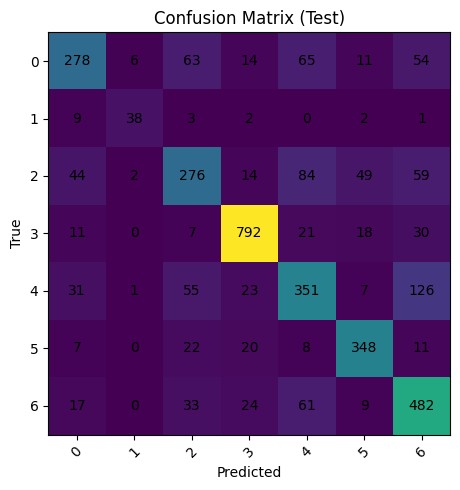

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
fig = plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(ticks=np.arange(num_classes), labels=[str(i) for i in range(num_classes)], rotation=45)
plt.yticks(ticks=np.arange(num_classes), labels=[str(i) for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout(); plt.show()

## Per-class Precision, Recall, and F1

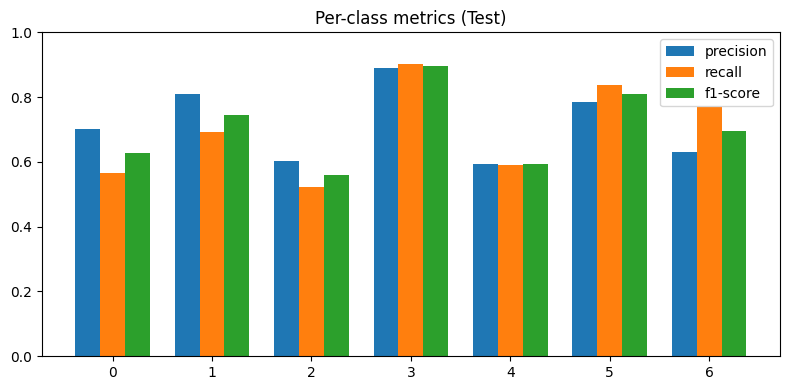

In [7]:
import matplotlib.pyplot as plt
import numpy as np
class_rows = [str(i) for i in range(num_classes) if str(i) in rep_df.index]
metrics = ['precision','recall','f1-score']
x = np.arange(len(class_rows))
width = 0.25
fig = plt.figure(figsize=(8,4))
for k, m in enumerate(metrics):
    vals = [rep_df.loc[c, m] for c in class_rows]
    plt.bar(x + (k-1)*width, vals, width, label=m)
plt.xticks(x, class_rows)
plt.ylim(0,1)
plt.title('Per-class metrics (Test)')
plt.legend(); plt.tight_layout(); plt.show()

## Sample Predictions (Random Test Images)

/tmp/ipython-input-2238052287.py:66: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L')


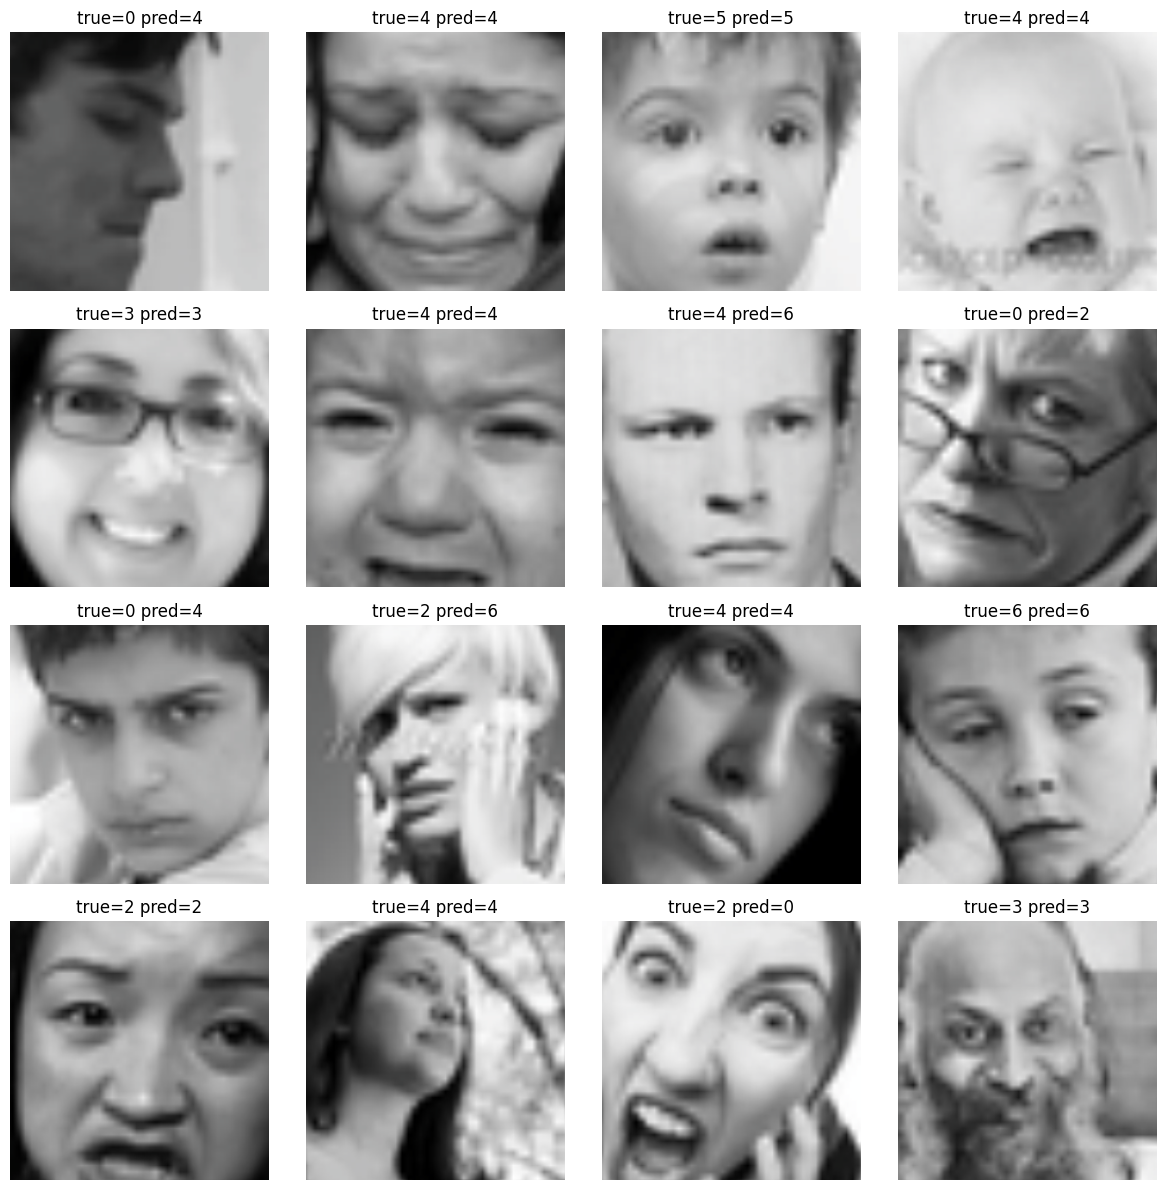

In [8]:
import matplotlib.pyplot as plt
import torch, numpy as np
def denorm(x):
    import numpy as _np
    mean = _np.array([0.485,0.456,0.406]).reshape(3,1,1)
    std = _np.array([0.229,0.224,0.225]).reshape(3,1,1)
    x = x.detach().cpu().numpy()
    x = (x * std) + mean
    x = _np.clip(x, 0, 1)
    return _np.transpose(x, (1,2,0))
student.eval()
n_show = 16
idxs = np.random.choice(len(ds_test), size=min(n_show, len(ds_test)), replace=False)
cols = 4
rows = int(np.ceil(len(idxs)/cols))
fig = plt.figure(figsize=(cols*3, rows*3))
for i, idx in enumerate(idxs):
    img, label = ds_test[idx]
    with torch.no_grad():
        logits = student(img.unsqueeze(0).to(DEVICE))
        pred = torch.argmax(logits, dim=1).item()
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(denorm(img))
    ax.set_title(f'true={label} pred={pred}')
    ax.axis('off')
plt.tight_layout(); plt.show()

## ROC Curves (One-vs-Rest)

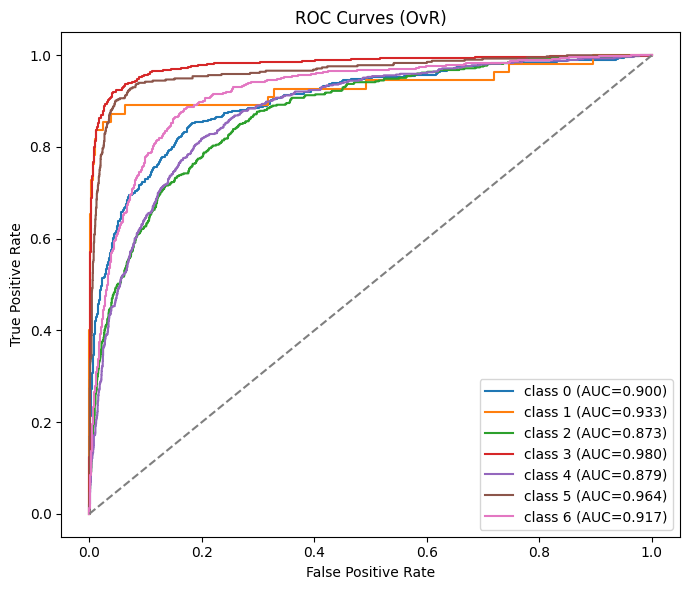

Per-class AUCs: [0.8999446459774981, 0.9327622575500333, 0.873074505261699, 0.9799894210546202, 0.8789494837074137, 0.9643139076098814, 0.9171420900369737]


In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
fig = plt.figure(figsize=(7,6))
aucs = []
for c in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,c], y_prob[:,c])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, label=f'class {c} (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (OvR)')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('Per-class AUCs:', [float(a) for a in aucs])

## Inference Latency and Throughput (Optional)

In [10]:
import time, torch
student.eval()
batch_sizes = [1, 8, 16, 32]
rows = []
for bs in batch_sizes:
    x = torch.randn(bs, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    for _ in range(5): _ = student(x)
    if DEVICE.type=='cuda': torch.cuda.synchronize()
    t0 = time.time(); _ = student(x)
    if DEVICE.type=='cuda': torch.cuda.synchronize()
    dt = (time.time()-t0) * 1000.0
    per_img = dt/bs; thr = (bs*1000.0)/max(dt,1e-9)
    rows.append((bs, dt, per_img, thr))
import pandas as pd
bench_df = pd.DataFrame(rows, columns=['batch_size','latency_ms_per_batch','latency_ms_per_image','throughput_imgs_per_sec'])
bench_df

,batch_size,latency_ms_per_batch,latency_ms_per_image,throughput_imgs_per_sec
0,1,8.146048,8.146048,122.758919
1,8,10.085583,1.260698,793.211479
2,16,6.916046,0.432253,2313.460563
3,32,11.511326,0.359729,2779.870925


## Accuracy, FLOPs, and Efficiency Comparison

In [11]:
teacher_acc = 0.723
teacher_gflops = 0.769
shuff_acc = 0.652
shuff_gflops = 0.039
mnv3_acc = float(acc)
mnv3_gflops = float(gflops_per_img)
import pandas as pd
rows = [
    ('Teacher_EffNetB0', teacher_acc*100.0, teacher_gflops, (teacher_acc*100.0)/teacher_gflops),
    ('Student_ShuffleV2x0.5', shuff_acc*100.0, shuff_gflops, (shuff_acc*100.0)/shuff_gflops),
    ('Student_MobileNetV3Small', mnv3_acc*100.0, mnv3_gflops, (mnv3_acc*100.0)/mnv3_gflops),
]
comp_df = pd.DataFrame(rows, columns=['model','accuracy_percent','gflops_per_img','efficiency'])
comp_df

,model,accuracy_percent,gflops_per_img,efficiency
0,Teacher_EffNetB0,72.300000,0.769000,94.018205
1,Student_ShuffleV2x0.5,65.200000,0.039000,1671.794872
2,Student_MobileNetV3Small,71.468376,0.055494,1287.867733


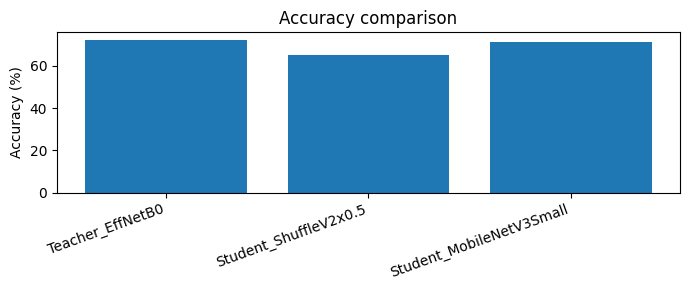

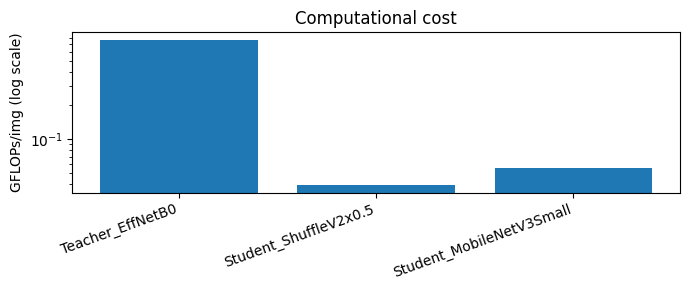

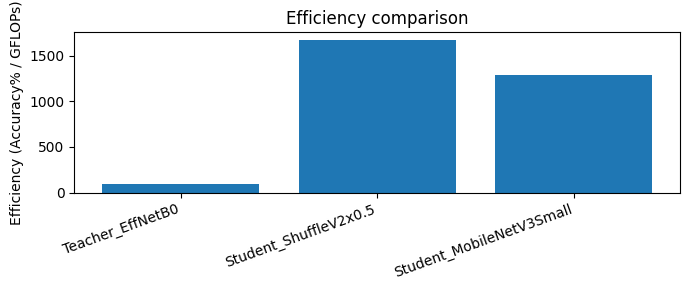

In [12]:
import matplotlib.pyplot as plt
import numpy as np
labels = comp_df['model'].tolist()
x = np.arange(len(labels))
fig = plt.figure(figsize=(7,3))
plt.bar(x, comp_df['accuracy_percent'].values)
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy comparison')
plt.tight_layout(); plt.show()
fig = plt.figure(figsize=(7,3))
plt.bar(x, comp_df['gflops_per_img'].values)
plt.yscale('log')
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('GFLOPs/img (log scale)')
plt.title('Computational cost')
plt.tight_layout(); plt.show()
fig = plt.figure(figsize=(7,3))
plt.bar(x, comp_df['efficiency'].values)
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('Efficiency (Accuracy% / GFLOPs)')
plt.title('Efficiency comparison')
plt.tight_layout(); plt.show()

This project implements the knowledge distillation to FER2013 facial expression recognition dataset as a small student model (MobileNetV3-Small) trains with a larger teacher model (EfficientNet-B0).

The dataset has been divided into a training, validation and test dataset, and data preprocessing was done by converting to grayscale, augmenting training data, and scaling using ImageNet statistics (Shorten, Khoshgoftaar, 2019). The teacher model (EfficientNet-B0) was also used in training and the student (MobileNetV3-Small) was trained using a combination of cross-entropy loss and soft-target Kullback-Leibler divergence objectives (Hinton et al., 2015).

The student model reached a test accuracy of 71.5%. The results were class specific with the highest F1 attained on the class 3 (0.896) and performance in the other emotions was very good as well (macro F1 = 0.703, weighted F1 = 0.712). Computational efficiency was also calculated The model consumed 0.055GFLOPs per image only with an efficiency score of 1287.9 (Accuracy% / GFLOPs). These findings show that although MobileNetV3-Small is less accurate than most of its counterparts, it is more efficient in comparison (Howard et al., 2019; Tan & Le, 2019).

In sum, the experiment illustrates that knowledge distillation can be used to deploy highly accurate but very lightweight models of emotion recognition applicable in real-time or limited-resources settings, representing a compromise between accuracy and real-time or low-compute applications.

**References**

Hinton, G., Vinyals, O. and Dean, J., 2015. Distilling the Knowledge in a Neural Network. arXiv preprint arXiv:1503.02531.

Howard, A., Sandler, M., Chu, G., Chen, L.C., Chen, B., Tan, M., Wang, W., Zhu, Y., Pang, R., Vasudevan, V. and Le, Q.V., 2019. Searching for MobileNetV3. Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV), pp. 1314–1324.

Shorten, C. and Khoshgoftaar, T.M., 2019. A survey on Image Data Augmentation for Deep Learning. Journal of Big Data, 6(1), pp.1–48.

Tan, M. and Le, Q., 2019. EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. Proceedings of the 36th International Conference on Machine Learning (ICML), pp.6105–6114.


